In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")





In [2]:
df = pd.read_csv('train.csv')
df.head(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S


In [3]:
df = pd.read_csv('train.csv')

df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace = True)
df.head()
                   

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


# check data



In [4]:
dtypes = df.dtypes
dtypes

Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin        object
Embarked     object
dtype: object

In [5]:

cols = ['Pclass' ,
        'Sex',
        'Survived',
        'SibSp',
        'Parch',
        'Embarked']
df[cols] = df[cols].astype("category")



In [6]:
df.shape[0] #get numbers of rows


891

In [7]:
meadian_1 = df['Age'].median()

meadian_1
df['Age'].fillna(meadian_1 , inplace=True)


In [8]:
df.dropna(subset=['Embarked'] , inplace=True)
df.drop("Cabin" , axis=1 , inplace=True)

In [9]:
#from preporessing import check_null

null = df.isnull().sum()
ratio = (null/df.shape[0])*100
pd.DataFrame({"null" : null , "ratio %" : ratio}).T


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio %,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


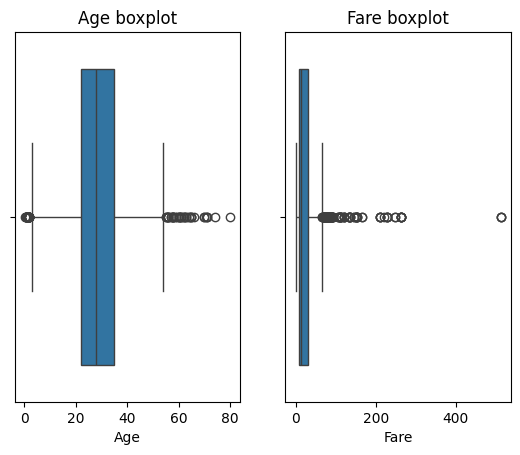

In [10]:
num_cols = df.select_dtypes("number").columns
plt.Figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col] , orient="h")
    plt.title(f"{col} boxplot")

In [11]:
for col in num_cols :
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    Lower_Fence = Q1 - 1.5*IQR
    Upper_Fence =Q3 + 1.5*IQR

    Lower_Outlier =  df[df[col] < Lower_Fence][col].values
    Upper_Outlier =  df[df[col] > Upper_Fence][col].values
    df[col].replace(Lower_Outlier , Lower_Fence , inplace= True)
    df[col].replace(Upper_Outlier , Upper_Fence , inplace= True)
    print(IQR)

13.0
23.1042


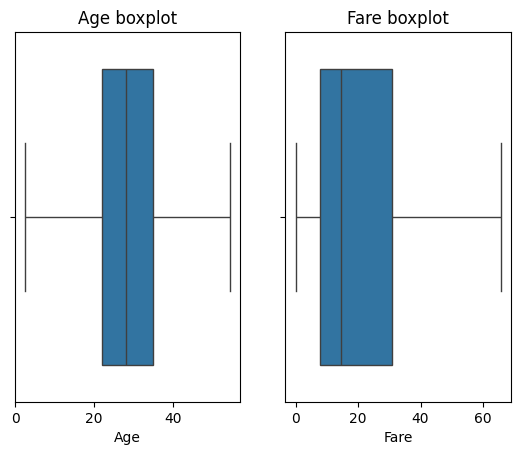

In [12]:
num_cols = df.select_dtypes("number").columns
plt.Figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col] , orient="h")
    plt.title(f"{col} boxplot")

In [13]:
df.duplicated().sum()
df.drop_duplicates(inplace= True)


In [14]:
df.duplicated().sum()

np.int64(0)

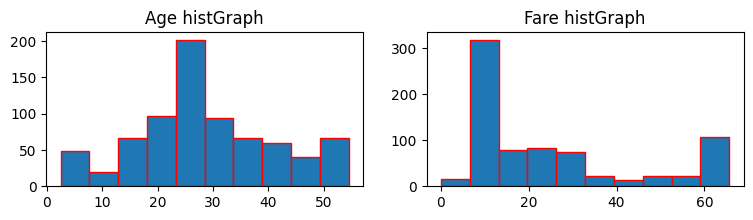

In [15]:
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(9,2))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    plt.hist(df[col] , edgecolor = "red")
    plt.title(f"{col} histGraph")
plt.show()

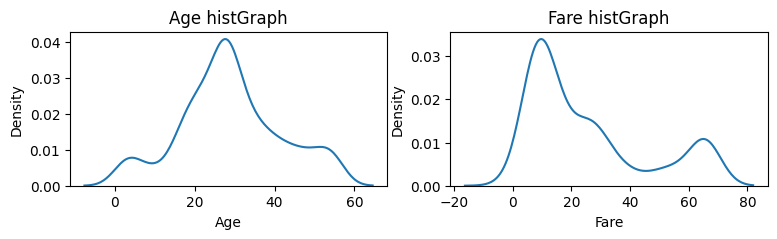

In [16]:
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(9,2))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.kdeplot(df[col] )
    plt.title(f"{col} histGraph")
plt.show()

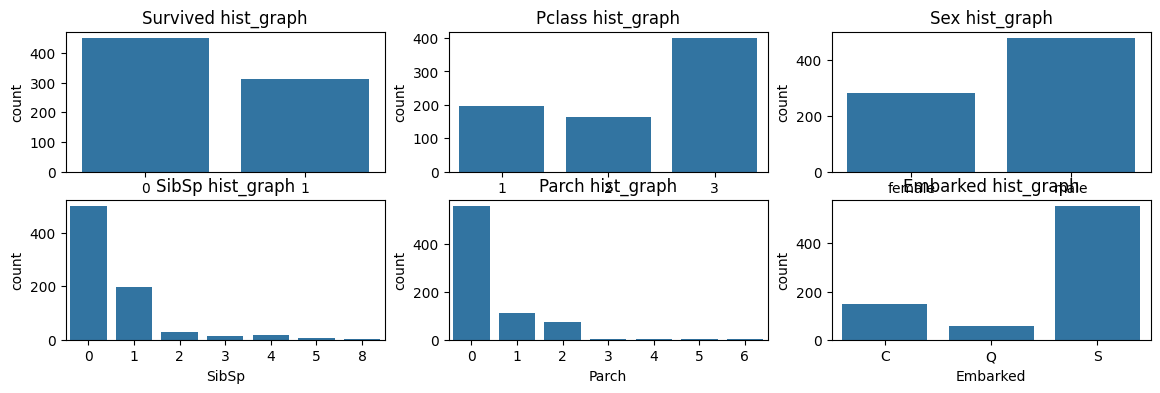

In [17]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(14,4))
for i , col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    sns.countplot(x=col , data=df )
    plt.title(f"{col} hist_graph")
plt.show()

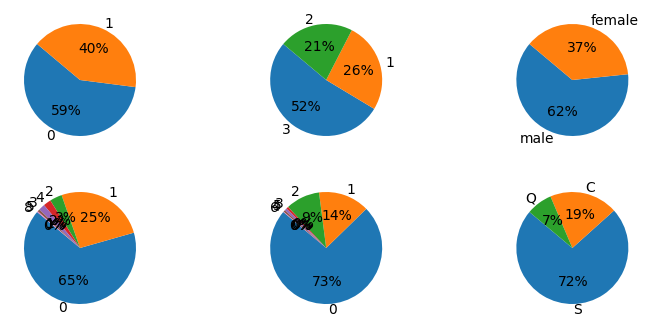

In [18]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(9,4))
for i , col in enumerate(cat_cols):
    plt.subplot(2,3 ,i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories = unique.index
    plt.pie(count , labels=categories , startangle=140 , autopct='%1.1d%%')

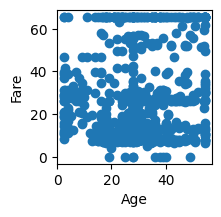

In [19]:
plt.figure(figsize=(2,2))
plt.scatter(df['Age'] , df['Fare'])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


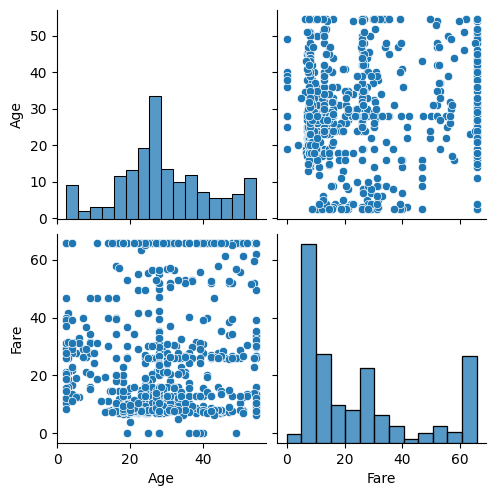

In [20]:
sns.pairplot(df)

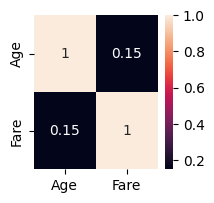

In [21]:
corr = df[num_cols].corr()
plt.figure(figsize=(2,2))
sns.heatmap(corr ,annot=True)
plt.show()

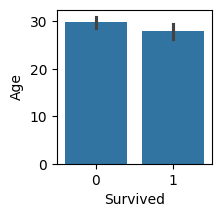

In [22]:
plt.figure(figsize=(2,2))
sns.barplot(x = "Survived" , y = "Age" , data=df)
plt.show()

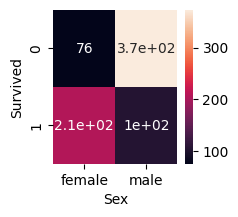

In [23]:
plt.figure(figsize=(2,2))
agg = df.pivot_table(index="Survived" , columns="Sex" , values="Age" , aggfunc=len)

sns.heatmap(agg ,annot=True)
plt.show()

In [25]:
x  = df.drop('Survived' , axis=1)
y = df['Survived']
y

0      0
1      1
2      1
3      1
4      0
      ..
885    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 760, dtype: category
Categories (2, int64): [0, 1]

In [27]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()
num_cols = x.select_dtypes("number").columns
x[num_cols] = scaler.fit_transform(x[num_cols])
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,0.375000,1,0,0.110424,S
1,1,female,0.682692,1,0,1.000000,C
2,3,female,0.451923,0,0,0.120704,S
3,1,female,0.625000,1,0,0.808757,S
4,3,male,0.625000,0,0,0.122608,S
...,...,...,...,...,...,...,...
885,3,female,0.701923,0,5,0.443598,Q
887,1,female,0.317308,0,0,0.456925,S
888,3,female,0.490385,1,2,0.357163,S
889,1,male,0.451923,0,0,0.456925,C


In [28]:
pip install category_endcoders

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement category_endcoders (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for category_endcoders


In [ ]:
%pip install category_encoders
from category_encoders import OneHotEncoder




ModuleNotFoundError: No module named 'category_encoders'